# N6 — Skills

* Professor: Júlio Cesar dos Reis <a href="mailto:dosreis@unicamp.br">(dosreis@unicamp.br)</a>
* Monitor: Alejandro Núñez Arroyo <a href="mailto:r299215@dac.unicamp.br">(r299215@dac.unicamp.br)</a>
* Material base: Renan dos Santos Morais <a href="mailto:r299211@dac.unicamp.br">(r299211@dac.unicamp.br)</a>

Este notebook trata do procedimento que um agente segue ao resolver uma tarefa recorrente: a ordem em que as ferramentas são chamadas, o critério de cada passo e o formato da resposta. Uma **skill** é esse procedimento escrito em texto, guardado fora do prompt de sistema e carregado por uma chamada de ferramenta quando o pedido do aluno corresponde à descrição dela.

As seções vão do procedimento escrito dentro do prompt de sistema até um agente que escolhe entre duas skills registradas em um catálogo. Nos dois arranjos as ferramentas chamadas são as mesmas; mudam a origem do texto que diz em que ordem chamá-las e o momento em que esse texto entra no contexto.

## 0.1 Pré-requisitos

Este notebook pressupõe os seguintes conhecimentos:

- Python: funções, dicionários, dataclasses e anotações de tipo;
- serialização de dados em JSON;
- tool calling, o mecanismo pelo qual o modelo devolve na resposta o nome de uma função declarada e os argumentos dela, e a aplicação executa a função e devolve o retorno ao modelo;
- o par pedido e observação em uma conversa com ferramentas, gravado em `AIMessage.tool_calls` e em `ToolMessage`;
- o decorador `@tool`, que extrai nome, descrição e esquema de argumentos de uma função Python;
- papéis das mensagens de uma conversa: sistema, usuário e assistente.

## 0.2 Objetivos da aula

Objetivos deste notebook:

1. Separar a ferramenta, que executa uma ação, da skill, que descreve o procedimento que combina ferramentas.
2. Escrever o corpo de uma skill com situação de uso, passos, formato da resposta e restrições.
3. Representar uma skill como estrutura de dados em Python, com os campos de um arquivo `SKILL.md`.
4. Distinguir os três níveis de carregamento: metadados, corpo e recursos.
5. Medir em caracteres o custo do nível de descoberta e o custo de uma ativação.
6. Expor a ativação de uma skill como ferramenta, chamável pelo modelo.
7. Montar um agente que lê a skill correspondente ao pedido antes de chamar as ferramentas do curso.
8. Registrar uma segunda skill e reconstruir o agente que guardou uma cópia do prompt de sistema.

## 0.3 Mapa do notebook

Conteúdo deste notebook:

1. Procedimento no prompt de sistema.
2. Anatomia de uma skill.
3. Skill como estrutura de dados.
4. Carregamento em três níveis.
5. Ferramentas do procedimento.
6. Agente com ativação de skill.
7. Catálogo com duas skills.
8. Exercícios de fixação.
9. Resumo da aula.
10. Referências.

## 0.4 Contexto usado nos exemplos

Os exemplos montam um assistente do curso de agentes com LLMs. O curso tem três módulos: `A4`, sobre estado, nós e transições, com 90 minutos; `A5`, sobre grafos com chamadas de modelo, com 120 minutos; e `A6`, sobre ferramentas e agentes, com 150 minutos. Os alunos Julio, Renan e Ana têm status e percentual registrados em cada módulo.

O assistente atende dois pedidos que têm procedimento fixo, definido pela coordenação do curso. O primeiro é o plano de estudo: consultar o progresso, somar a duração dos módulos que faltam, converter a soma em dias e distribuir o resultado em blocos semanais. O segundo é a liberação de módulo: consultar o progresso e comparar o percentual do módulo em andamento com o limite de 80. Esses dois procedimentos são o material das skills escritas ao longo do notebook.

## 0.5 Preparação do ambiente

O notebook usa o modelo `gpt-oss:120b`, executado na infraestrutura do Ollama e acessado pela API em `https://ollama.com`. Nenhum modelo é baixado na máquina. A seção 0.6 registra também a configuração do Gemini, para o caso de a execução ser feita pela API do Google.

As bibliotecas são `langchain` (decorador `@tool` e `create_agent`), `langgraph` (grafo do agente e desenho dele), `langchain-ollama` e `langchain-google-genai` (clientes dos dois provedores) e `python-dotenv` (leitura da chave). O `langchain-google-genai` só é carregado quando a constante `PROVEDOR` da seção 0.6 tem o valor `"gemini"`.

As seções 1 a 5 constroem as skills e as ferramentas em Python puro e rodam sem chamar modelo. Das seções 6 e 7 em diante, a execução depende de tool calling. O `gpt-oss:120b` e o `gemini-3.5-flash-lite` têm essa capacidade. Um modelo sem ela responde em texto, `tool_calls` volta como lista vazia, e o agente responde sem ler a skill e sem consultar o progresso.

O acesso ao modelo hospedado exige uma chave de API. Os passos para obtê-la:

1. Criar uma conta em [ollama.com](https://ollama.com) e entrar nela.
2. Abrir [ollama.com/settings/keys](https://ollama.com/settings/keys) e gerar uma chave nova.
3. Copiar o valor exibido, que aparece uma única vez.
4. Guardar o valor na variável de ambiente `OLLAMA_API_KEY`.

Há três formas de cumprir o passo 4. Em uma máquina local, escreva a linha `OLLAMA_API_KEY=...` em um arquivo `.env` ao lado do notebook, que já está no `.gitignore`, e deixe o `load_dotenv()` da seção 0.6 carregá-la. A segunda forma é exportar a variável no ambiente antes de abrir o notebook. A terceira é a célula comentada abaixo, para o Google Colab. Não escreva a chave no código versionado.

A execução pelo Gemini segue o mesmo caminho, com a chave gerada em [aistudio.google.com/apikey](https://aistudio.google.com/apikey) e guardada em `GOOGLE_API_KEY`. As duas chaves cabem no mesmo `.env`, e `criar_modelo` lê apenas a do provedor selecionado.

In [1]:
# Descomente se estiver em um ambiente sem as dependências instaladas.
# %pip install -U langchain langgraph langchain-ollama langchain-google-genai python-dotenv

A célula a seguir cobre o caso do Google Colab, onde não há arquivo `.env`. Descomente as três linhas, cole a chave entre as aspas e execute a célula. Torne a comentá-las antes de salvar o notebook, para que a chave não seja gravada no arquivo.

In [2]:
# # Descomente no Google Colab, onde não há arquivo .env.
# import os
# os.environ["OLLAMA_API_KEY"] = ""
# os.environ["GOOGLE_API_KEY"] = ""

Agora importamos os elementos que serão usados ao longo da aula.

In [3]:
import json
import math
import os

from dataclasses import dataclass, field

from dotenv import load_dotenv

from langchain.agents import create_agent
from langchain.tools import tool
from langchain_core.language_models import BaseChatModel
from langchain_core.messages import AnyMessage, HumanMessage, ToolMessage
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_ollama import ChatOllama
from langchain_openai import ChatOpenAI

from langgraph.graph.state import CompiledStateGraph

from IPython.display import Image, display

Glossário dos imports:

- `json`: serialização do retorno das ferramentas e impressão dos metadados do catálogo;
- `math`: arredondamento para cima no cálculo de dias de estudo;
- `os` e `load_dotenv`: leitura das chaves de API a partir do ambiente ou do arquivo `.env`;
- `dataclass` e `field`: declaração da classe `Skill` com os campos de um arquivo `SKILL.md`;
- `create_agent`: monta o grafo do agente com ferramentas a partir do modelo, da lista de ferramentas e do prompt de sistema;
- `tool`: decorador que converte uma função Python em ferramenta com nome, descrição e esquema;
- `AnyMessage`: tipo comum às mensagens, usado nas anotações das funções auxiliares;
- `HumanMessage` e `ToolMessage`: o pedido do aluno e o resultado de uma ferramenta;
- `BaseChatModel`: classe base dos dois clientes, usada na anotação de retorno de `criar_modelo`;
- `ChatOllama` e `ChatGoogleGenerativeAI`: clientes dos dois provedores configurados na seção 0.6;
- `CompiledStateGraph`: tipo do grafo devolvido por `create_agent`, usado na anotação de `display_graph`;
- `Image` e `display`: exibição do desenho do grafo dentro do notebook.

As duas funções auxiliares abaixo são usadas nas células de exemplo. A primeira exibe o desenho de um grafo compilado; a segunda imprime uma conversa mensagem a mensagem, com os pedidos de chamada separados do texto.

In [4]:
def display_graph(graph: CompiledStateGraph) -> None:
    """Renderiza o grafo compilado como imagem PNG."""
    display(Image(graph.get_graph().draw_mermaid_png()))


def mostrar_conversa(mensagens: list[AnyMessage]) -> None:
    """Imprime cada mensagem com o tipo, os pedidos de chamada e o conteúdo."""
    for indice, mensagem in enumerate(mensagens):
        print(f"[{indice}] {type(mensagem).__name__}")

        for chamada in getattr(mensagem, "tool_calls", []):
            print(f"    pedido: {chamada['name']}({chamada['args']})")

        if mensagem.text:
            rotulo = "resultado" if isinstance(mensagem, ToolMessage) else "texto"
            print(f"    {rotulo}: {mensagem.text[:300]}")

        print("-" * 60)

## 0.6 Escolhendo um provedor de LLM

O notebook instancia o modelo por uma função única, `criar_modelo`, e as seções seguintes chamam o objeto devolvido por ela. A constante `PROVEDOR` seleciona qual cliente é construído.

Os dois provedores diferem nos pontos da tabela abaixo, e `criar_modelo` concentra os que afetam a construção do cliente:

| Ponto | Ollama | Gemini |
|---|---|---|
| Classe | `ChatOllama` | `ChatGoogleGenerativeAI` |
| Conexão | `base_url` em `https://ollama.com` e cabeçalho `Authorization` entregue por `client_kwargs` | chave entregue em `api_key` |
| Limite de tokens da resposta | `num_predict` | `max_output_tokens` |
| Amostragem | `temperature` | fixa; a família Gemini 3.x não aceita `temperature`, `top_p` nem `top_k` |
| Raciocínio | `reasoning` | `thinking_level`, com os valores `minimal`, `low`, `medium` e `high` |
| Campo `content` da resposta | uma string | uma lista de blocos |

A interface de tool calling é a mesma nos dois: `create_agent` recebe a lista de ferramentas, e o pedido de chamada chega em `tool_calls`, com o mesmo formato de dicionário. A diferença de formato do `content` fica coberta por `mensagem.text`, que devolve string nas duas representações; `mostrar_conversa` imprime esse campo. As células das seções 6 e 7 não mudam com a troca de `PROVEDOR`.

As saídas gravadas neste arquivo vêm do Ollama. Para executar pelo Gemini, gere uma chave em [aistudio.google.com/apikey](https://aistudio.google.com/apikey), guarde-a na variável `GOOGLE_API_KEY` e troque o valor de `PROVEDOR`.

O parâmetro `reasoning=False` retira o texto de raciocínio do `gpt-oss` do campo da resposta. Os tokens de raciocínio continuam sendo gerados e continuam contando no orçamento de `num_predict`. Quando o orçamento acaba antes da resposta visível, a chamada volta com `done_reason` igual a `length` e sem texto. O valor 2000 de `LIMITE_RESPOSTA` cobre o percurso mais longo das seções 6 e 7, que tem quatro chamadas de modelo.

In [5]:
load_dotenv()

PROVEDOR = "llama-cpp"  # opções: "llama-cpp", "ollama", "gemini"

MODELO_LLAMA_CPP = os.environ.get("LLAMA_CPP_MODEL", "bonsai2-pq2-0")
URL_LLAMA_CPP = os.environ.get("LLAMA_CPP_BASE_URL", "http://localhost:8079/v1")

MODELO_OLLAMA = "gpt-oss:120b"           # servido por https://ollama.com
MODELO_GEMINI = "gemini-3.5-flash-lite"  # servido pela API do Google AI Studio

URL_OLLAMA = "https://ollama.com"
TEMPERATURA = 0
LIMITE_RESPOSTA = 2000  # tokens gerados por chamada


def criar_modelo(provedor: str = PROVEDOR):
    """Instancia o cliente do provedor escolhido com o mesmo orçamento de geração."""
    if provedor in ("llama-cpp", "openai", "local"):
        return ChatOpenAI(
            model=MODELO_LLAMA_CPP,
            base_url=URL_LLAMA_CPP,
            api_key=os.environ.get("OPENAI_API_KEY", "not-needed"),
            temperature=TEMPERATURA,
            max_tokens=LIMITE_RESPOSTA,
        )

    if provedor == "ollama":
        chave = os.environ.get("OLLAMA_API_KEY")
        if not chave:
            raise RuntimeError(
                "OLLAMA_API_KEY não encontrada. Gere uma chave em "
                "https://ollama.com/settings/keys e defina a variável no arquivo .env, "
                "no ambiente do sistema ou na célula da seção 0.5."
            )

        return ChatOllama(
            model=MODELO_OLLAMA,
            base_url=URL_OLLAMA,
            client_kwargs={"headers": {"Authorization": f"Bearer {chave}"}},
            reasoning=False,
            temperature=TEMPERATURA,
            num_predict=LIMITE_RESPOSTA,
        )

    if provedor == "gemini":
        chave = os.environ.get("GOOGLE_API_KEY")
        if not chave:
            raise RuntimeError(
                "GOOGLE_API_KEY não encontrada. Gere uma chave em "
                "https://aistudio.google.com/apikey e defina a variável no arquivo .env "
                "ou no ambiente do sistema."
            )

        return ChatGoogleGenerativeAI(
            model=MODELO_GEMINI,
            api_key=chave,
            max_output_tokens=LIMITE_RESPOSTA,
            thinking_level="low",
        )

    raise RuntimeError(f"Provedor não reconhecido: {provedor}. Use 'llama-cpp', 'ollama' ou 'gemini.")


modelo = criar_modelo()

print(PROVEDOR, "|", type(modelo).__name__)

llama-cpp | ChatOpenAI


---

# 1. Procedimento no prompt de sistema

Um agente com ferramentas recebe, a cada chamada, a declaração de cada ferramenta e as mensagens da conversa. O prompt de sistema é a parte fixa desse envio: ele vai junto em toda chamada, com o mesmo texto, qualquer que seja o pedido do aluno.

Os dois procedimentos do curso descritos na seção 0.4 têm passos, critérios e formato de resposta próprios. Os dois cabem dentro do prompt de sistema, e as células abaixo os escrevem ali para medir o tamanho do resultado.

In [6]:
PROCEDIMENTO_PLANO = """# Planejar estudo

## Situação de uso
Pedido de plano, cronograma ou sequência de estudo para as próximas semanas.

## Passos
1. Chame `consultar_progresso` com o nome do aluno.
2. Some a duração dos módulos cujo status não é `concluido`.
3. Chame `calcular_dias_de_estudo` com essa soma e com 45 minutos por dia.
4. Distribua a carga em no máximo 3 blocos semanais.
5. Coloque o módulo com status `em_andamento` no primeiro bloco.

## Formato da resposta
- Uma linha por bloco, com o código do módulo e a duração do bloco.
- Uma linha final com o total de dias devolvido pela ferramenta.

## Restrições
- Não cite módulo que não veio do progresso consultado.
- Não estime prazo sem o resultado de `calcular_dias_de_estudo`.
"""

PROCEDIMENTO_LIBERACAO = """# Liberar próximo módulo

## Situação de uso
Pedido de liberação, autorização ou parecer sobre iniciar o módulo seguinte.

## Passos
1. Chame `consultar_progresso` com o nome do aluno.
2. Localize o módulo com status `em_andamento`.
3. Com percentual abaixo de 80, responda que o aluno ainda não deve avançar.
4. Com percentual igual ou acima de 80, responda que o aluno pode avançar.

## Formato da resposta
- Primeira linha: `pode avancar` ou `ainda nao`.
- Segunda linha: o código do módulo em andamento e o percentual consultado.
"""

O prompt de sistema abaixo contém os dois procedimentos por extenso. É o texto que acompanharia toda chamada de modelo, inclusive as que não pedem plano nem liberação.

In [7]:
PROMPT_COM_PROCEDIMENTOS = f"""Atue como assistente do curso de agentes com LLMs.
O curso tem os módulos A4, A5 e A6.

{PROCEDIMENTO_PLANO}
{PROCEDIMENTO_LIBERACAO}
Responda em português, em no máximo seis linhas."""

print("procedimento do plano:     ", len(PROCEDIMENTO_PLANO), "caracteres")
print("procedimento da liberação: ", len(PROCEDIMENTO_LIBERACAO), "caracteres")
print("prompt de sistema inteiro: ", len(PROMPT_COM_PROCEDIMENTOS), "caracteres")

procedimento do plano:      725 caracteres
procedimento da liberação:  534 caracteres
prompt de sistema inteiro:  1397 caracteres


## 1.1 Discussão

Os dois procedimentos ocupam 1259 dos 1397 caracteres do prompt de sistema, e o restante são três linhas de enquadramento. Uma pergunta como "quanto dura o módulo A6?" é respondida por uma consulta ao progresso, e carrega junto os passos do plano de estudo e o critério de liberação.

Duas propriedades desse arranjo aparecem quando o número de procedimentos cresce:

- custo: o texto de cada procedimento entra em cada chamada de modelo, e o total cresce com o número de procedimentos cadastrados, não com o que o pedido usa;
- manutenção: alterar o limite de 80 do critério de liberação exige editar a string que também carrega o plano de estudo, e as duas partes são versionadas juntas.

O restante do notebook mantém os mesmos dois textos e muda o lugar deles. Os procedimentos saem do prompt de sistema e passam a ser buscados por uma chamada de ferramenta, com o prompt guardando apenas o nome e a descrição de cada um.

---

# 2. Anatomia de uma skill

Uma **skill** é um procedimento em texto, com um nome, uma descrição da situação em que se aplica e um corpo com os passos. Nas ferramentas que implementam o formato, uma skill é um diretório com um arquivo `SKILL.md` obrigatório e arquivos de apoio opcionais:

```text
planejar-estudo/
├── SKILL.md      ← obrigatório: metadados e instruções
├── scripts/      ← opcional: código executável chamado pelas instruções
├── references/   ← opcional: documentação consultada pelas instruções
└── assets/       ← opcional: modelos e arquivos estáticos
```

O `SKILL.md` tem duas partes. A primeira é o frontmatter em YAML, com o nome e a descrição:

```yaml
---
name: planejar-estudo
description: Monta um plano de estudo semanal a partir do progresso registrado e da duração dos módulos que faltam
---
```

A segunda parte é o corpo, em markdown, com os passos, os critérios e o formato da resposta. Os textos da seção 1 têm essa forma. Os arquivos de `scripts/`, `references/` e `assets/` são lidos quando os passos do corpo os citam, e ficam fora do contexto no restante do tempo.

## 2.1 Ferramenta e skill

As duas peças aparecem na mesma conversa e ocupam posições diferentes:

| Ponto | Ferramenta | Skill |
|---|---|---|
| Conteúdo | uma função Python com esquema de argumentos | um texto com passos e critérios |
| Execução | o código da aplicação roda a função | o modelo lê o texto e emite os pedidos seguintes |
| Retorno | o resultado da função, em uma `ToolMessage` | o próprio texto do procedimento |
| Presença no contexto | nome, descrição e esquema em toda chamada | nome e descrição em toda chamada; corpo só depois da ativação |
| Efeito de um erro | uma consulta devolve dado errado | o modelo segue a ordem errada de consultas |

Uma skill não acrescenta ação ao agente. As funções chamadas depois da ativação são as mesmas que já estavam declaradas, e o corpo da skill fixa a ordem, os valores dos argumentos e o formato do texto final.

---

# 3. Skill como estrutura de dados

A classe abaixo tem os campos do `SKILL.md`: `nome` e `descricao` vêm do frontmatter, `corpo` é o markdown, `ferramentas` registra quais funções o corpo cita, e `recursos` associa o nome de cada arquivo de apoio ao conteúdo dele. O método `metadados` devolve o par que fica visível antes de qualquer ativação.

In [8]:
@dataclass
class Skill:
    nome: str
    descricao: str
    corpo: str
    ferramentas: list[str] = field(default_factory=list)
    recursos: dict[str, str] = field(default_factory=dict)

    def metadados(self) -> dict:
        """Devolve o par nome e descrição, que é o nível visível sem ativação."""
        return {"nome": self.nome, "descricao": self.descricao}


skill_plano = Skill(
    nome="planejar-estudo",
    descricao=(
        "Monta um plano de estudo semanal para um aluno do curso, a partir do "
        "progresso registrado e da duração dos módulos que faltam."
    ),
    corpo=PROCEDIMENTO_PLANO,
    ferramentas=["consultar_progresso", "calcular_dias_de_estudo"],
)

print(json.dumps(skill_plano.metadados(), ensure_ascii=False, indent=2))
print("corpo:", len(skill_plano.corpo), "caracteres")

{
  "nome": "planejar-estudo",
  "descricao": "Monta um plano de estudo semanal para um aluno do curso, a partir do progresso registrado e da duração dos módulos que faltam."
}
corpo: 725 caracteres


## 3.1 Discussão

O campo `descricao` é o único texto comparado com o pedido do aluno na decisão de ativar a skill, porque é o único que o modelo tem antes de ler o corpo. Ele nomeia a situação de uso e a entrada esperada, e o corpo trata do resto.

O campo `ferramentas` é documentação. Nada no código verifica que o corpo cita essas funções, nem que o modelo chama só essas depois de ler o corpo. O exercício 5 compara essa lista com as ferramentas de fato chamadas em uma execução.

---

# 4. Carregamento em três níveis

O texto de uma skill entra no contexto em três momentos, e cada um traz uma quantidade diferente de informação:

```text
nível 1 — descoberta   nome e descrição de cada skill, no prompt de sistema
   ↓ o pedido corresponde à descrição
nível 2 — ativação     corpo da skill, devolvido por uma chamada de ferramenta
   ↓ os passos do corpo citam um arquivo
nível 3 — recursos     arquivo de scripts/, references/ ou assets/
```

O catálogo abaixo tem um método por nível: `descobrir` devolve os metadados de todas as skills registradas, `ativar` devolve o corpo de uma delas, e `recurso` devolve um arquivo de apoio. Um nome ausente cai na convenção de erro das ferramentas do curso: um objeto JSON com a chave `erro` e a lista de valores aceitos, no lugar de uma exceção.

O registro indexa pelo nome. Chamar `registrar` com um nome já presente substitui a skill anterior, e é assim que uma edição do corpo entra no catálogo.

In [9]:
class CatalogoSkills:
    """Guarda as skills registradas e responde pelos três níveis de carregamento."""

    def __init__(self) -> None:
        self._skills: dict[str, Skill] = {}

    def registrar(self, skill: Skill) -> None:
        self._skills[skill.nome] = skill

    def descobrir(self) -> list[dict]:
        """Nível 1: metadados de todas as skills registradas."""
        return [skill.metadados() for skill in self._skills.values()]

    def ativar(self, nome: str) -> str:
        """Nível 2: corpo de uma skill, ou o objeto de erro com os nomes aceitos."""
        skill = self._skills.get(nome)

        if skill is None:
            return json.dumps(
                {"erro": "skill_desconhecida", "skills_disponiveis": list(self._skills)},
                ensure_ascii=False,
            )

        return skill.corpo

    def recurso(self, nome: str, arquivo: str) -> str:
        """Nível 3: conteúdo de um arquivo de apoio, ou o objeto de erro."""
        skill = self._skills.get(nome)

        if skill is None or arquivo not in skill.recursos:
            return json.dumps(
                {
                    "erro": "recurso_desconhecido",
                    "recursos_disponiveis": list(skill.recursos) if skill else [],
                },
                ensure_ascii=False,
            )

        return skill.recursos[arquivo]


CATALOGO = CatalogoSkills()
CATALOGO.registrar(skill_plano)

print(json.dumps(CATALOGO.descobrir(), ensure_ascii=False, indent=2))

[
  {
    "nome": "planejar-estudo",
    "descricao": "Monta um plano de estudo semanal para um aluno do curso, a partir do progresso registrado e da duração dos módulos que faltam."
  }
]


## 4.1 Custo de cada nível

As duas primeiras chamadas abaixo medem em caracteres o que os níveis 1 e 2 trazem para o contexto. As duas últimas pedem uma skill ausente do catálogo e um arquivo de apoio, e mostram o retorno nesses dois casos.

In [10]:
descoberta = json.dumps(CATALOGO.descobrir(), ensure_ascii=False)

print("nível 1, descoberta:", len(descoberta), "caracteres")
print("nível 2, ativação:  ", len(CATALOGO.ativar("planejar-estudo")), "caracteres")
print()
print(CATALOGO.ativar("emitir-certificado"))
print(CATALOGO.recurso("planejar-estudo", "references/blocos.md"))

nível 1, descoberta: 172 caracteres
nível 2, ativação:   725 caracteres

{"erro": "skill_desconhecida", "skills_disponiveis": ["planejar-estudo"]}
{"erro": "recurso_desconhecido", "recursos_disponiveis": []}


## 4.2 Leitura da execução

Para esta skill, o nível 1 tem 172 caracteres e entra em toda chamada de modelo; o nível 2 tem 725 e entra quando o modelo pede. Uma conversa que não trata de plano de estudo termina sem o corpo.

A relação entre os dois números depende do que cada skill contém, e a diferença entre os dois arranjos cresce com o número de skills registradas. No prompt da seção 1, o custo por chamada é a soma dos corpos de todos os procedimentos. No catálogo, o custo por chamada é a soma das descrições, mais o corpo das skills ativadas naquela conversa.

O nome ausente devolveu o objeto com `erro` e a lista de nomes registrados. Quando essa string chega ao modelo dentro de uma `ToolMessage`, os nomes aceitos vão junto, e o pedido seguinte pode corrigir o nome. Uma exceção no lugar do objeto interromperia a execução do agente.

O último retorno é do nível 3, com a mesma convenção. As skills deste notebook têm `recursos` vazio, e a lista de arquivos disponíveis volta vazia junto com o erro. O nível chega ao modelo quando uma ferramenta expõe `recurso` e os passos de uma skill citam o arquivo. O exercício 4 escreve as duas peças.

---

# 5. Ferramentas do procedimento

As duas ferramentas abaixo são as que os corpos das skills citam. A primeira lê o progresso de um aluno em um dicionário, que ocupa o lugar de uma API de sistema acadêmico. A segunda converte uma carga de estudo em número de dias. As duas devolvem string JSON e seguem a mesma convenção de erro do catálogo.

In [11]:
DURACAO_MODULOS = {"A4": 90, "A5": 120, "A6": 150}

PROGRESSO = {
    "julio": {"A4": ("concluido", 100), "A5": ("concluido", 100), "A6": ("nao_iniciado", 0)},
    "renan": {"A4": ("concluido", 100), "A5": ("em_andamento", 50), "A6": ("nao_iniciado", 0)},
    "ana": {"A4": ("em_andamento", 70), "A5": ("nao_iniciado", 0), "A6": ("nao_iniciado", 0)},
}


@tool(parse_docstring=True)
def consultar_progresso(nome_aluno: str) -> str:
    """Consulta o status, o percentual e a duração de cada módulo do curso para um aluno.

    Args:
        nome_aluno: primeiro nome do aluno, como Julio, Renan ou Ana.
    """
    chave = nome_aluno.strip().lower()

    if chave not in PROGRESSO:
        return json.dumps(
            {"erro": "aluno_desconhecido", "alunos_disponiveis": list(PROGRESSO)},
            ensure_ascii=False,
        )

    return json.dumps(
        {
            "aluno": chave,
            "modulos": [
                {
                    "modulo": modulo,
                    "status": status,
                    "percentual": percentual,
                    "duracao_min": DURACAO_MODULOS[modulo],
                }
                for modulo, (status, percentual) in PROGRESSO[chave].items()
            ],
        },
        ensure_ascii=False,
    )


@tool(parse_docstring=True)
def calcular_dias_de_estudo(carga_minutos: int, minutos_por_dia: int) -> str:
    """Calcula em quantos dias uma carga de estudo cabe na disponibilidade diária.

    Args:
        carga_minutos: soma da duração dos módulos em minutos.
        minutos_por_dia: minutos disponíveis por dia de estudo.
    """
    if carga_minutos <= 0 or minutos_por_dia <= 0:
        return json.dumps(
            {"erro": "valor_invalido", "mensagem": "Os dois valores devem ser positivos."},
            ensure_ascii=False,
        )

    dias = math.ceil(carga_minutos / minutos_por_dia)

    return json.dumps(
        {
            "carga_minutos": carga_minutos,
            "minutos_por_dia": minutos_por_dia,
            "dias": dias,
            "carga_formatada": f"{carga_minutos // 60}h{carga_minutos % 60:02d}min",
        },
        ensure_ascii=False,
    )


print(consultar_progresso.invoke({"nome_aluno": "renan"}))
print(calcular_dias_de_estudo.invoke({"carga_minutos": 270, "minutos_por_dia": 45}))

{"aluno": "renan", "modulos": [{"modulo": "A4", "status": "concluido", "percentual": 100, "duracao_min": 90}, {"modulo": "A5", "status": "em_andamento", "percentual": 50, "duracao_min": 120}, {"modulo": "A6", "status": "nao_iniciado", "percentual": 0, "duracao_min": 150}]}
{"carga_minutos": 270, "minutos_por_dia": 45, "dias": 6, "carga_formatada": "4h30min"}


## 5.1 Ativação como ferramenta

A ativação de uma skill chega ao modelo pelo mesmo caminho de qualquer outra função: uma ferramenta declarada, com nome, descrição e esquema de argumentos. A ferramenta abaixo recebe o nome da skill e devolve o corpo dela, ou o objeto de erro do catálogo.

In [12]:
@tool(parse_docstring=True)
def ler_skill(nome: str) -> str:
    """Lê o procedimento completo de uma skill do catálogo, pelo nome.

    Args:
        nome: nome da skill, como aparece na lista de skills disponíveis.
    """
    return CATALOGO.ativar(nome)


FERRAMENTAS = [consultar_progresso, calcular_dias_de_estudo, ler_skill]

for ferramenta in FERRAMENTAS:
    print(ferramenta.name, "|", list(ferramenta.args))

consultar_progresso | ['nome_aluno']
calcular_dias_de_estudo | ['carga_minutos', 'minutos_por_dia']
ler_skill | ['nome']


## 5.2 Discussão

`ler_skill` consulta o catálogo em cada chamada, e não guarda cópia do corpo. Uma alteração no texto de uma skill já registrada alcança a próxima ativação sem que nada seja reconstruído. A subseção 7.3 volta a esse ponto, porque o nome e a descrição não se comportam assim.

A ferramenta não restringe o nome pedido a um conjunto fechado. O esquema declara `nome` como string livre, e a lista de nomes válidos chega ao modelo pelo prompt de sistema da seção 6. Um nome fora do catálogo devolve o objeto com `erro` e a lista de nomes aceitos, no lugar de interromper a execução.

---

# 6. Agente com ativação de skill

O prompt de sistema desta seção carrega o nível 1: uma linha por skill registrada, com nome e descrição. Os passos de cada procedimento ficam fora dele.

`create_agent` monta o grafo do agente: um nó chama o modelo com o prompt de sistema e o histórico, um `ToolNode` executa os pedidos de chamada, e uma aresta condicional repete o par enquanto a resposta trouxer pedidos. Os argumentos são o modelo, a lista de ferramentas e o prompt.

Fluxo esperado para um pedido que corresponde a uma skill:

```text
pedido do aluno
  ↓
modelo lê nome e descrição no prompt de sistema
  ↓
ler_skill("planejar-estudo")   → corpo do procedimento
  ↓
consultar_progresso("Renan")   → status e duração dos módulos
  ↓
calcular_dias_de_estudo(...)   → número de dias
  ↓
resposta no formato que o corpo da skill descreve
```

In [13]:
def montar_prompt() -> str:
    """Escreve o prompt de sistema com uma linha por skill registrada no catálogo."""
    linhas = "\n".join(
        f"- {metadados['nome']}: {metadados['descricao']}"
        for metadados in CATALOGO.descobrir()
    )

    return f"""Atue como assistente do curso de agentes com LLMs.
O curso tem os módulos A4, A5 e A6.

Skills disponíveis:
{linhas}

Quando o pedido do aluno corresponder à descrição de uma skill, chame ler_skill
com o nome dela antes de qualquer outra ferramenta, e siga o procedimento devolvido.
Quando não corresponder, responda usando as demais ferramentas.
Responda em português, em no máximo seis linhas."""


print(montar_prompt())

Atue como assistente do curso de agentes com LLMs.
O curso tem os módulos A4, A5 e A6.

Skills disponíveis:
- planejar-estudo: Monta um plano de estudo semanal para um aluno do curso, a partir do progresso registrado e da duração dos módulos que faltam.

Quando o pedido do aluno corresponder à descrição de uma skill, chame ler_skill
com o nome dela antes de qualquer outra ferramenta, e siga o procedimento devolvido.
Quando não corresponder, responda usando as demais ferramentas.
Responda em português, em no máximo seis linhas.


[0] HumanMessage
    texto: Sou o aluno Renan. Monte um plano de estudo para as próximas semanas.
------------------------------------------------------------
[1] AIMessage
    pedido: ler_skill({'nome': 'planejar-estudo'})
------------------------------------------------------------
[2] ToolMessage
    resultado: # Planejar estudo

## Situação de uso
Pedido de plano, cronograma ou sequência de estudo para as próximas semanas.

## Passos
1. Chame `consultar_progresso` com o nome do aluno.
2. Some a duração dos módulos cujo status não é `concluido`.
3. Chame `calcular_dias_de_estudo` com essa soma e com 45 min
------------------------------------------------------------
[3] AIMessage
    pedido: consultar_progresso({'nome_aluno': 'Renan'})
------------------------------------------------------------
[4] ToolMessage
    resultado: {"aluno": "renan", "modulos": [{"modulo": "A4", "status": "concluido", "percentual": 100, "duracao_min": 90}, {"modulo": "A5", "status": "em_andamento", "perce

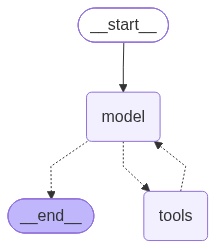

In [14]:
agente = create_agent(
    model=modelo,
    tools=FERRAMENTAS,
    system_prompt=montar_prompt(),
)

resultado_plano = agente.invoke(
    {
        "messages": [
            HumanMessage(
                "Sou o aluno Renan. Monte um plano de estudo para as próximas semanas."
            )
        ]
    }
)

mostrar_conversa(resultado_plano["messages"])

display_graph(agente)

## 6.1 Leitura da execução

A execução gravada acima percorreu esta sequência:

1. O modelo recebeu o prompt de sistema com a linha de `planejar-estudo` e o pedido do aluno.
2. A primeira `AIMessage` trouxe o pedido `ler_skill(nome="planejar-estudo")`.
3. A `ToolMessage` seguinte trouxe o corpo do procedimento, que até então não estava no contexto.
4. As duas chamadas seguintes reproduzem os passos 1 e 3 do corpo: `consultar_progresso` e depois `calcular_dias_de_estudo`, com a soma das durações dos módulos que faltam como argumento.
5. A última `AIMessage` traz o texto no formato descrito na seção "Formato da resposta" do corpo.

A ordem das duas consultas não está no prompt de sistema nem no código do agente. O grafo alterna entre chamar o modelo e executar ferramentas, e a sequência dos passos 4 e 5 veio do texto lido no passo 3.

O argumento de `calcular_dias_de_estudo` depende do resultado de `consultar_progresso`, e por isso as duas chamadas ficam em respostas sucessivas nos dois provedores. Consultas independentes entre si não têm essa restrição: o modelo pode emitir os dois pedidos na mesma `AIMessage`, e o histórico fecha com uma mensagem a menos.

## 6.2 Pedido sem skill correspondente

O agente decide a ativação comparando o pedido com as descrições do prompt. A pergunta abaixo é respondida por uma das ferramentas do curso e não corresponde à descrição de nenhuma skill registrada.

In [15]:
resultado_direto = agente.invoke(
    {
        "messages": [
            HumanMessage("Em quantos dias eu estudo 300 minutos a 45 minutos por dia?")
        ]
    }
)

mostrar_conversa(resultado_direto["messages"])

[0] HumanMessage
    texto: Em quantos dias eu estudo 300 minutos a 45 minutos por dia?
------------------------------------------------------------
[1] AIMessage
    pedido: calcular_dias_de_estudo({'carga_minutos': 300, 'minutos_por_dia': 45})
------------------------------------------------------------
[2] ToolMessage
    resultado: {"carga_minutos": 300, "minutos_por_dia": 45, "dias": 7, "carga_formatada": "5h00min"}
------------------------------------------------------------
[3] AIMessage
    texto: 300 minutos a 45 minutos por dia equivalem a **7 dias** de estudo (carga total de 5h00min).
------------------------------------------------------------


## 6.3 Discussão

O histórico desta execução não tem `ler_skill`. O modelo chamou `calcular_dias_de_estudo` com os dois valores tirados do enunciado e respondeu, e o corpo da skill `planejar-estudo` não entrou no contexto em nenhum momento. No prompt da seção 1, os passos do plano de estudo acompanhariam esta pergunta; com o catálogo, o pedido carregou uma linha de descrição.

A decisão de ativar é do modelo, tomada sobre o texto da descrição. A aplicação não classifica o pedido antes de chamá-lo, e o grafo não tem nó nem aresta ligados a skills: `ler_skill` é uma ferramenta como as outras duas.

---

# 7. Catálogo com duas skills

O procedimento de liberação de módulo escrito na seção 1 vira a segunda skill do catálogo. O registro é uma chamada de `registrar`, e nenhuma parte do código do agente muda. Com as duas skills registradas, os dois arranjos passam a cobrir o mesmo material, e a célula abaixo compara o tamanho dos dois prompts de sistema.

In [16]:
skill_liberacao = Skill(
    nome="liberar-proximo-modulo",
    descricao=(
        "Decide se um aluno pode iniciar o próximo módulo, a partir do percentual "
        "do módulo em andamento no progresso registrado."
    ),
    corpo=PROCEDIMENTO_LIBERACAO,
    ferramentas=["consultar_progresso"],
)

CATALOGO.registrar(skill_liberacao)

print(json.dumps(CATALOGO.descobrir(), ensure_ascii=False, indent=2))
print()
print("prompt com os dois procedimentos:", len(PROMPT_COM_PROCEDIMENTOS), "caracteres")
print("prompt com as duas descrições:   ", len(montar_prompt()), "caracteres")

[
  {
    "nome": "planejar-estudo",
    "descricao": "Monta um plano de estudo semanal para um aluno do curso, a partir do progresso registrado e da duração dos módulos que faltam."
  },
  {
    "nome": "liberar-proximo-modulo",
    "descricao": "Decide se um aluno pode iniciar o próximo módulo, a partir do percentual do módulo em andamento no progresso registrado."
  }
]

prompt com os dois procedimentos: 1397 caracteres
prompt com as duas descrições:    679 caracteres


Os dois prompts cobrem os mesmos dois procedimentos, com 679 caracteres no do catálogo contra 1397 no da seção 1. A diferença corresponde ao corpo das duas skills, que entra no contexto por `ler_skill` nas conversas que o pedem.

## 7.1 Reconstrução do agente

O agente da seção 6 recebeu o prompt de sistema como string, no momento da construção. A chamada de `montar_prompt` aconteceu ali, e o texto guardado dentro do agente tem uma skill só. Registrar a segunda no catálogo não altera esse texto.

A célula abaixo constrói um agente novo com o prompt refeito. O pedido enviado a ele corresponde à descrição da segunda skill, e não à da primeira.

In [17]:
agente_com_duas_skills = create_agent(
    model=modelo,
    tools=FERRAMENTAS,
    system_prompt=montar_prompt(),
)

resultado_liberacao = agente_com_duas_skills.invoke(
    {"messages": [HumanMessage("Sou a aluna Ana. Já posso começar o módulo A5?")]}
)

mostrar_conversa(resultado_liberacao["messages"])

[0] HumanMessage
    texto: Sou a aluna Ana. Já posso começar o módulo A5?
------------------------------------------------------------
[1] AIMessage
    pedido: ler_skill({'nome': 'liberar-proximo-modulo'})
------------------------------------------------------------
[2] ToolMessage
    resultado: # Liberar próximo módulo

## Situação de uso
Pedido de liberação, autorização ou parecer sobre iniciar o módulo seguinte.

## Passos
1. Chame `consultar_progresso` com o nome do aluno.
2. Localize o módulo com status `em_andamento`.
3. Com percentual abaixo de 80, responda que o aluno ainda não deve
------------------------------------------------------------
[3] AIMessage
    pedido: consultar_progresso({'nome_aluno': 'Ana'})
------------------------------------------------------------
[4] ToolMessage
    resultado: {"aluno": "ana", "modulos": [{"modulo": "A4", "status": "em_andamento", "percentual": 70, "duracao_min": 90}, {"modulo": "A5", "status": "nao_iniciado", "percentual": 0, "duraca

## 7.2 Leitura da execução

O modelo pediu `ler_skill(nome="liberar-proximo-modulo")` e não `planejar-estudo`. As duas descrições estavam no mesmo prompt, e a seleção foi feita sobre elas: o pedido cita iniciar um módulo, e a descrição da segunda skill nomeia essa situação. O corpo da primeira skill não entrou no contexto desta conversa.

Depois da ativação, o percurso segue o corpo lido: uma chamada de `consultar_progresso`, o módulo `A4` com status `em_andamento` e percentual 70, e a comparação com o limite de 80 escrito no passo 3. A resposta traz o veredito e o módulo com o percentual consultado, os dois itens que a seção "Formato da resposta" do corpo pede. Esta execução tem uma chamada de ferramenta a menos que a da seção 6, porque o corpo desta skill cita uma ferramenta e o da outra cita duas.

## 7.3 Momento de leitura de cada campo

Os três campos de uma skill entram no contexto em momentos diferentes, e uma alteração em cada um alcança o agente de maneira diferente:

| Campo | Onde entra | Efeito de uma alteração |
|---|---|---|
| `nome` | prompt de sistema, escrito na construção | exige refazer `montar_prompt` e reconstruir o agente |
| `descricao` | prompt de sistema, escrito na construção | exige refazer `montar_prompt` e reconstruir o agente |
| `corpo` | `ToolMessage`, buscado a cada ativação | alcança a próxima execução do agente já construído |

O agente guarda uma cópia do texto que recebeu em `system_prompt`, e o catálogo continua sendo consultado por `ler_skill` a cada chamada. Registrar uma skill, renomear uma existente ou reescrever uma descrição são alterações do primeiro grupo, e a construção do agente entra junto na célula.

O corpo concentra os passos e os critérios de um procedimento. Um ajuste no limite de 80, ou no número de blocos semanais, é uma edição de string seguida de `registrar`.

---

# 8. Exercícios de fixação

Os exercícios modificam exemplos já executados. Use as células vazias abaixo de cada enunciado.

## Exercício 1 — Formato da resposta no corpo

Reescreva a seção "Formato da resposta" de `PROCEDIMENTO_PLANO` pedindo uma tabela markdown com as colunas `bloco`, `modulo` e `minutos`. Registre a skill de novo com `CATALOGO.registrar(Skill(...))`, mantendo nome e descrição, e envie a `agente_com_duas_skills` o pedido de plano de estudo do Renan. Reporte se a resposta saiu em tabela e se foi preciso reconstruir o agente.

## Exercício 2 — Terceira skill no catálogo

Escreva a skill `comparar-progresso`, com descrição que nomeie a situação "comparar o progresso de dois alunos" e corpo com os passos de consultar os dois nomes e listar quem está em cada módulo. Registre-a, construa um agente novo com o prompt refeito e peça a comparação entre Julio e Ana. Reporte qual skill foi ativada e quantas chamadas de `consultar_progresso` apareceram no histórico.

## Exercício 3 — Encadeamento entre skills

Acrescente ao início dos passos de `PROCEDIMENTO_PLANO` uma instrução para chamar `ler_skill` com o nome `liberar-proximo-modulo` e aplicar o critério de lá antes de montar o plano. Registre a skill de novo com `CATALOGO.registrar(Skill(...))`, mantendo nome e descrição, e peça a `agente_com_duas_skills` o plano de estudo da Ana. Reporte quantos pedidos de `ler_skill` aparecem no histórico e em que ordem.

## Exercício 4 — Nível 3, recursos da skill

O catálogo devolve arquivos de apoio por `recurso`, e nenhuma ferramenta expõe esse método ao modelo. Escreva a ferramenta `ler_recurso(skill: str, arquivo: str)` sobre ele. Registre de novo a skill de plano de estudo com um recurso `references/blocos.md` que descreva a divisão em blocos, cite esse arquivo no passo 4 do corpo, e construa um agente com as quatro ferramentas. Reporte se `ler_recurso` foi chamada.

## Exercício 5 — Ferramentas declaradas e ferramentas chamadas

O campo `ferramentas` de uma `Skill` é documentação e nada o verifica. Escreva uma função que recebe a lista de mensagens de uma execução e devolve os nomes das ferramentas chamadas, sem `ler_skill`. Aplique-a a `resultado_plano["messages"]`, o histórico do pedido de plano de estudo do Renan, e compare com `skill_plano.ferramentas`. Reporte se os dois conjuntos coincidem.

## Exercício 6 — Momento de cada alteração

Sem executar código, indique quais das alterações abaixo alcançam a próxima chamada de `agente_com_duas_skills` e quais exigem construir o agente de novo: acrescentar um passo ao corpo de `planejar-estudo`; trocar a descrição de `liberar-proximo-modulo`; registrar uma skill nova; acrescentar uma ferramenta a `FERRAMENTAS`. Justifique cada resposta pelo momento em que o texto ou a lista é lida.

---

# 9. Resumo da aula

O notebook tirou dois procedimentos do prompt de sistema e os transformou em skills de um catálogo, lidas por uma chamada de ferramenta. As funções Python chamadas depois da ativação são as mesmas dos dois arranjos, e o corpo da skill fixa a ordem das chamadas e o formato da resposta.

| Conceito | Ideia principal |
|---|---|
| Skill | Procedimento em texto, com situação de uso, passos, formato da resposta e restrições. |
| `SKILL.md` | Arquivo com frontmatter YAML de `name` e `description`, e corpo em markdown. |
| Nível de descoberta | Nome e descrição de cada skill, presentes em toda chamada de modelo. |
| Nível de ativação | Corpo da skill, entregue em uma `ToolMessage` quando o modelo pede. |
| Nível de recursos | Arquivos de apoio, lidos quando os passos do corpo os citam. |
| `descricao` | Único texto comparado com o pedido do aluno na decisão de ativar. |
| Catálogo | Estrutura que responde por descoberta e ativação, consultada a cada chamada. |
| Ativação como ferramenta | `ler_skill` é declarada e executada como qualquer outra função. |
| Cópia do prompt | O agente guarda o texto recebido em `system_prompt`; nome e descrição novos exigem reconstrução. |
| Custo por conversa | Soma das descrições, mais o corpo das skills ativadas naquela conversa. |

## 9.1 Checklist de compreensão

Questões de verificação:

1. Que informação de uma skill está no contexto antes de qualquer ativação, e qual só entra depois?
2. Por que a decisão de ativar uma skill é tomada sobre a descrição, e não sobre o corpo?
3. Que caminho o corpo de uma skill percorre até chegar ao modelo?
4. O que acontece com o histórico de uma conversa cujo pedido não corresponde a nenhuma descrição registrada?
5. Por que registrar uma skill nova não alcança um agente já construído?
6. Por que editar o corpo de uma skill registrada alcança a execução seguinte sem reconstrução?
7. Quando o arranjo do prompt de sistema com os procedimentos por extenso custa menos que o catálogo?
8. O que o campo `ferramentas` de uma `Skill` diz sobre as funções chamadas depois da ativação, e o que o código verifica a respeito?

## 9.2 Próximos passos

- Skills em arquivos `SKILL.md` no disco, com o catálogo lendo o diretório e o frontmatter YAML;
- nível 3 com scripts executáveis, em que os passos do corpo apontam um arquivo para executar em vez de descrever o cálculo;
- subagentes com catálogos próprios, cada um com o conjunto de skills do seu domínio;
- registro de qual skill foi ativada em cada conversa, para revisar descrições que competem entre si;
- ferramentas expostas por servidores externos, chamadas pelo corpo de uma skill do mesmo modo que as locais;
- versionamento das skills junto com o código do agente, com o corpo revisado por quem define o procedimento.

---

# 10. Referências

- LangChain, ferramentas: https://docs.langchain.com/oss/python/langchain/tools
- LangChain, mensagens: https://docs.langchain.com/oss/python/langchain/messages
- LangChain, agentes: https://docs.langchain.com/oss/python/langchain/agents
- LangGraph, Graph API: https://docs.langchain.com/oss/python/langgraph/graph-api
- Referência de API, `tool`: https://reference.langchain.com/python/langchain-core/tools/convert/tool
- Referência de API, `create_agent`: https://reference.langchain.com/python/langchain/agents/factory/create_agent
- Referência de API, `ChatOllama`: https://reference.langchain.com/python/langchain-ollama/chat_models/ChatOllama
- Referência de API, `ChatGoogleGenerativeAI`: https://reference.langchain.com/python/langchain-google-genai/chat_models/ChatGoogleGenerativeAI
- Anthropic, Agent Skills: https://platform.claude.com/docs/en/agents-and-tools/agent-skills/overview
- Anthropic, escrita de skills: https://platform.claude.com/docs/en/agents-and-tools/agent-skills/best-practices
- Ollama, documentação: https://docs.ollama.com
- Gemini, mudanças de parâmetros nos modelos recentes: https://ai.google.dev/gemini-api/docs/generate-content/latest-model#api-changes-and-parameter-updates